# ECON 424 Final Project
Ethan Tran

November 2025

# Q1.
The following introduces the data set.

The data are Glassdoor reviews. Training data sets (small: 100,00 observations, large: 500,000 observations; small is not a subset of large; you can use both training sets) are posted on Learn. 

The test data set has 100,000 observations. Test data set without the response variable is also already posted on Learn.

Some feature variables may have missing values. In the prediction competition you cannot skip observations with missing values on some features: you must give some prediction for all 100,000 observations in the test set.

### a)

Construct features from the available data. Then use these features to predict the overall rating using any machine learning model. (For this question, you should not use LLM APIs.)

You can utilize either or both training data sets to train the model.

Performance of the algorithm is measured by the accuracy percentage in the test set.

In [14]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud
import lightgbm as lgb

In [15]:
# Load data
train_small = pd.read_csv("424_F2025_Final_PC_small_train_v1.csv")
train_large = pd.read_csv("424_F2025_Final_PC_large_train_v1.csv")
test_ds = pd.read_csv("424_F2025_Final_PC_test_without_response_v1.csv")
ds = pd.concat([train_small, train_large], ignore_index=True)

text_cols = ["headline", "pros", "cons"]
cat_cols = ["firm", "job_title"]
num_cols = ["year_review"]
target = "rating"

# Fill missing
for c in text_cols:
    ds[c] = ds[c].fillna("")
    test_ds[c] = test_ds[c].fillna("")
for c in cat_cols:
    ds[c] = ds[c].fillna("Unknown")
    test_ds[c] = test_ds[c].fillna("Unknown")

In [16]:
# Feature engineering
ds["full_text"] = ds["headline"] + " " + ds["pros"] + " " + ds["cons"]
test_ds["full_text"] = test_ds["headline"] + " " + test_ds["pros"] + " " + test_ds["cons"]

In [17]:
# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    ds, ds[target], test_size=0.2, random_state=42
)

In [18]:
# Column transformer
tfidf = TfidfVectorizer(
    max_features=60000,
    ngram_range=(1, 2),
    stop_words="english"
)

ohe = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("text", tfidf, "full_text"),
        ("cat", ohe, cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

In [19]:
# Model
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

pipeline = Pipeline([
    ("prep", preprocess),
    ("model", model)
])

In [20]:
# Train model
pipeline.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 92.029844 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1183839
[LightGBM] [Info] Number of data points in the train set: 480000, number of used features: 59716
[LightGBM] [Info] Start training from score -2.935735
[LightGBM] [Info] Start training from score -2.601609
[LightGBM] [Info] Start training from score -1.442353
[LightGBM] [Info] Start training from score -1.050805
[LightGBM] [Info] Start training from score -1.249224


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
# Validation accuracy
val_pred = pipeline.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
print("Validation Accuracy:", val_acc * 100)

c:\Users\vecto\Downloads\ECON 424\Final Project\ECON424-Final-Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation Accuracy: 51.48416666666667


In [22]:
# Fit on full data
pipeline.fit(ds, ds[target])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 72.946475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1189485
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 62186
[LightGBM] [Info] Start training from score -2.938628
[LightGBM] [Info] Start training from score -2.602452
[LightGBM] [Info] Start training from score -1.443098
[LightGBM] [Info] Start training from score -1.051328
[LightGBM] [Info] Start training from score -1.247223


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
# Predict
test_pred = pipeline.predict(test_ds)

# Save prediction CSV in competition format
out = pd.DataFrame({
    "prediction": test_pred
})
out.to_csv("Q1_submission_predictions.csv", index=False)
print("Saved predictions to Q1_submission_predictions.csv")

c:\Users\vecto\Downloads\ECON 424\Final Project\ECON424-Final-Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved predictions to Q1_submission_predictions.csv


### b)

Produce graphs to illustrate the following (we have drawn all of these in previous prediction competitions):

• Word cloud for 5 star reviews versus word cloud for 1 star reviews

• Importance of each feature.

• Distribution of each feature in the training data versus in the test data.

• Confusion matrix (in the training data).

• How large and common are prediction errors at different points of the distribution of the response variable in the training data (in other words, contrast distributions for y vs. ˆy, or distributions for y versus ˆu).

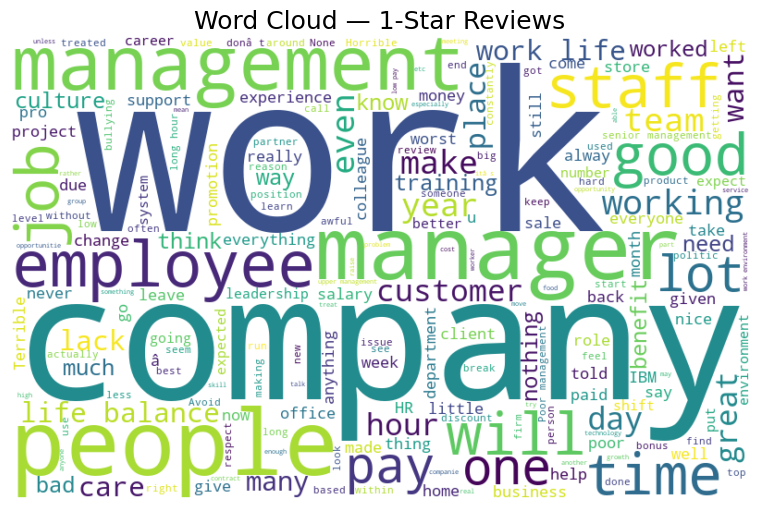

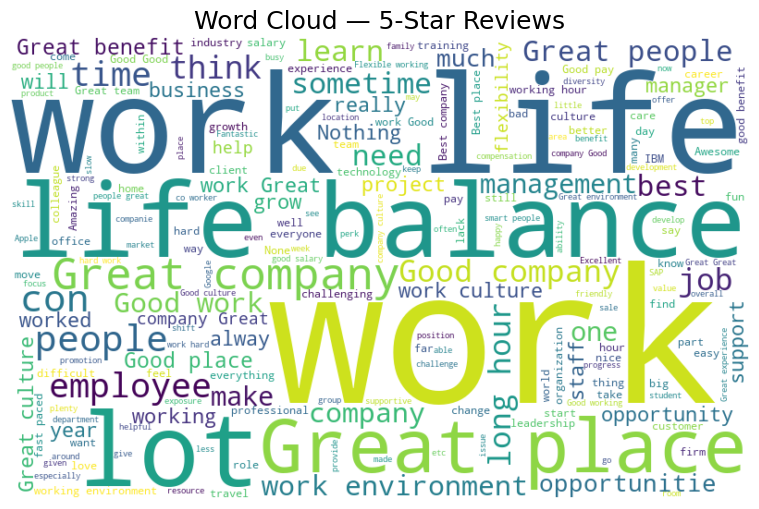

In [25]:
# Word cloud
def make_wordcloud(text, title):
    wc = WordCloud(width=800, height=500, background_color="white").generate(text)
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(title, fontsize=18)
    plt.axis("off")
    plt.show()

text_1 = " ".join(ds[ds[target] == 1]["full_text"].tolist())
text_5 = " ".join(ds[ds[target] == 5]["full_text"].tolist())

make_wordcloud(text_1, "Word Cloud — 1-Star Reviews")
make_wordcloud(text_5, "Word Cloud — 5-Star Reviews")

Number of features: 110408
Importance values: 110408


C:\Users\vecto\AppData\Local\Temp\ipykernel_14152\2344485911.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


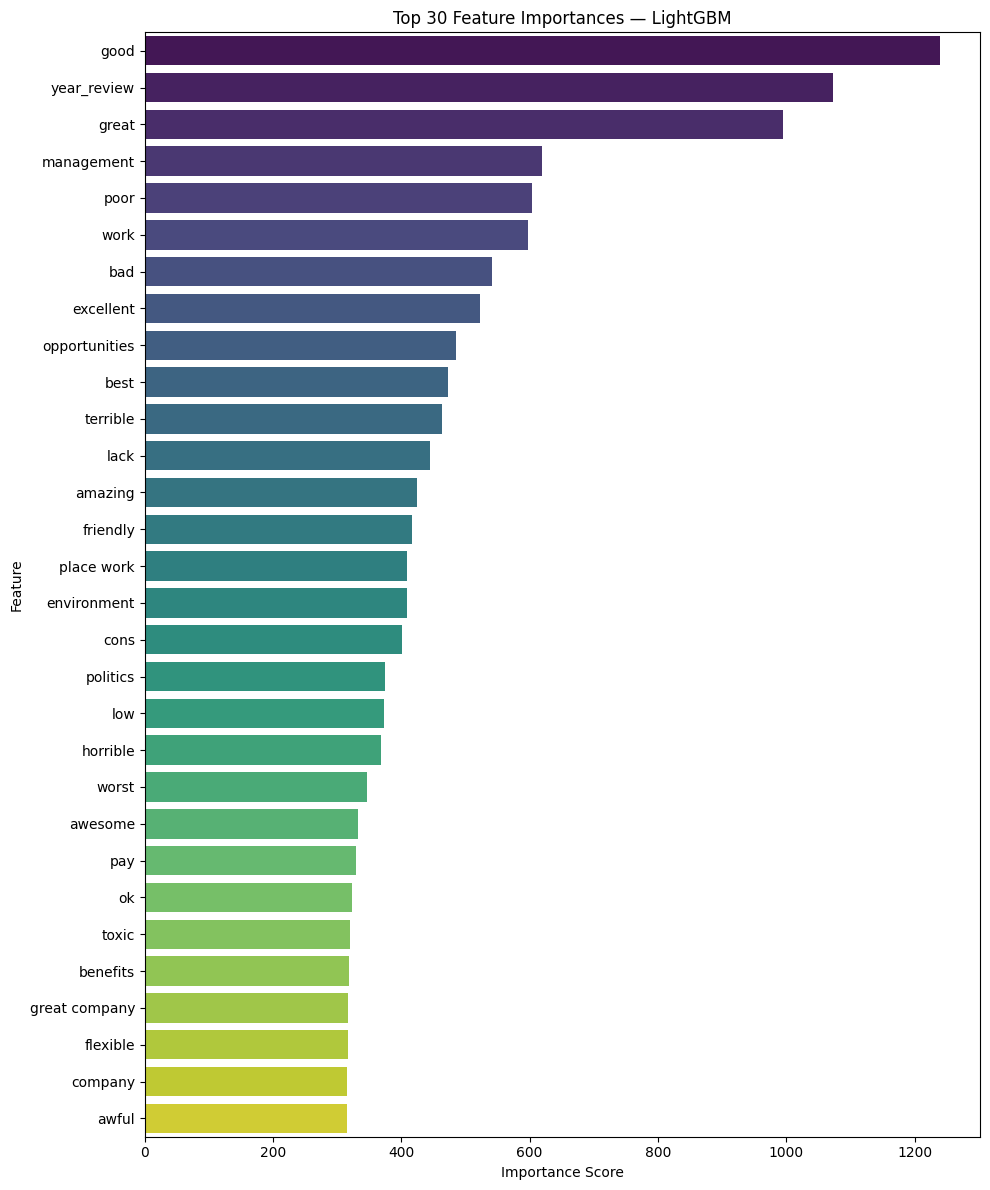

In [29]:
# Feature importance

# Extract fitted components
fitted_prep = pipeline.named_steps["prep"]
fitted_model = pipeline.named_steps["model"]

# ---- 1. Text feature names (TF-IDF) ----
tfidf_fitted = fitted_prep.named_transformers_["text"]
tfidf_features = tfidf_fitted.get_feature_names_out()

# ---- 2. OneHotEncoder feature names ----
ohe_fitted = fitted_prep.named_transformers_["cat"]
ohe_features = ohe_fitted.get_feature_names_out(cat_cols)

# ---- 3. Numeric features ----
numeric_features = num_cols

# Combine all feature names in correct order
all_features = np.concatenate([
    tfidf_features,
    ohe_features,
    numeric_features
])

# ---- 4. Extract feature importances from LightGBM ----
importances = fitted_model.feature_importances_

# Safety check (dimension alignment)
print("Number of features:", len(all_features))
print("Importance values:", len(importances))

# Create DataFrame
fi = pd.DataFrame({
    "feature": all_features,
    "importance": importances
})

# Sort and keep top 30 (otherwise text features dominate graph size)
fi_top = fi.sort_values("importance", ascending=False).head(30)

# ---- 5. Plot Feature Importance ----
plt.figure(figsize=(10, 12))
sns.barplot(
    data=fi_top,
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 30 Feature Importances — LightGBM")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

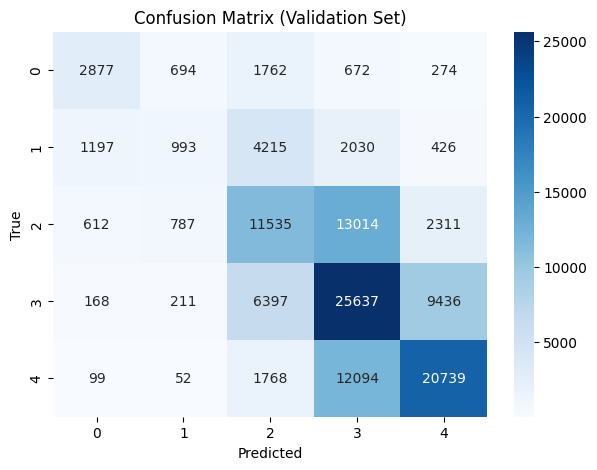

In [26]:
# Confusion matrix
cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Validation Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

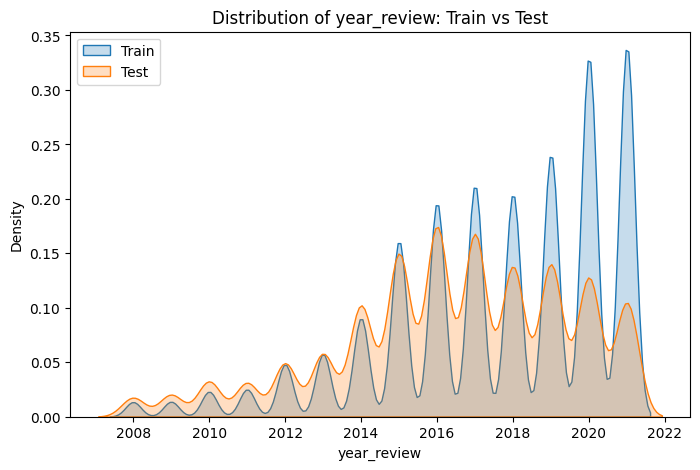

<Figure size 800x500 with 0 Axes>

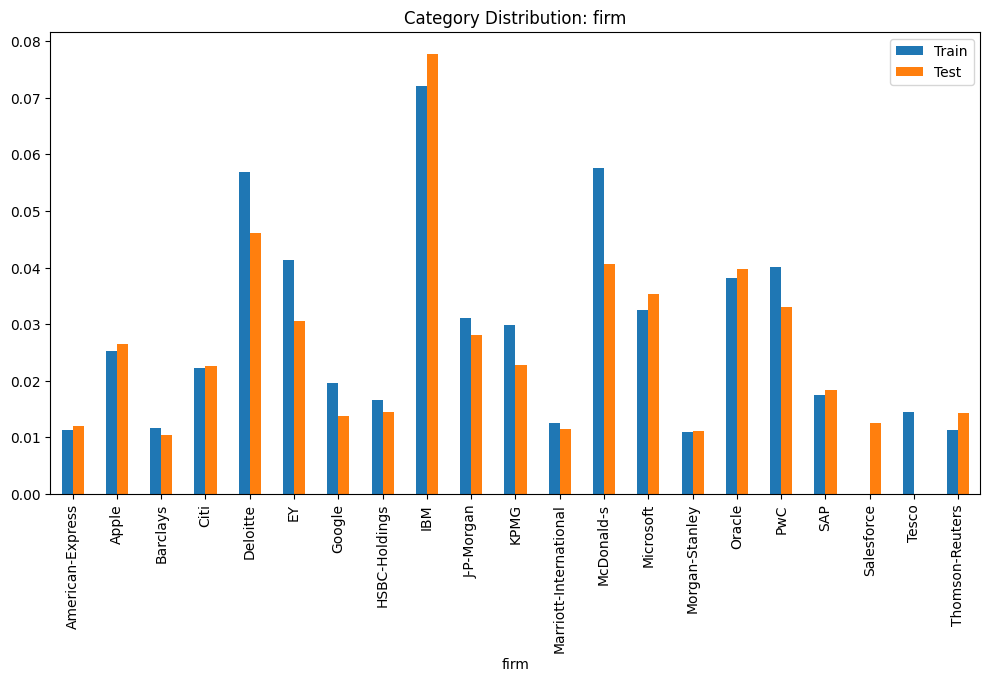

<Figure size 800x500 with 0 Axes>

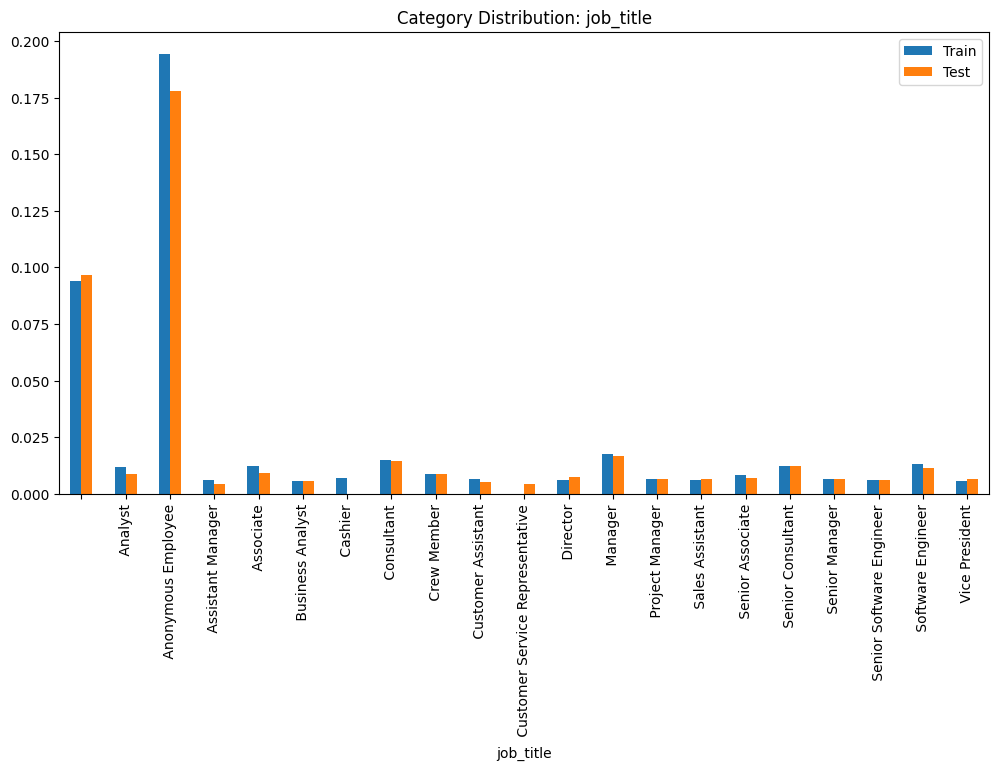

In [ ]:
# Feature distribution for train vs. test data
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(ds[col], label="Train", fill=True)
    sns.kdeplot(test_ds[col], label="Test", fill=True)
    plt.title(f"Distribution of {col}: Train vs Test")
    plt.legend()
    plt.show()

for col in cat_cols:
    plt.figure(figsize=(8, 5))
    train_counts = ds[col].value_counts(normalize=True).head(20)
    test_counts = test_ds[col].value_counts(normalize=True).head(20)
    compare_df = pd.DataFrame({"Train": train_counts, "Test": test_counts}).fillna(0)

    compare_df.plot(kind="bar", figsize=(12, 6))
    plt.title(f"Category Distribution: {col}")
    plt.show()

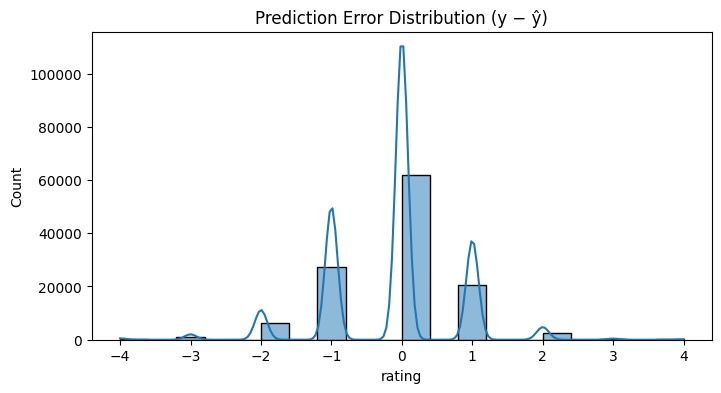

In [28]:
# Prediction-error distribution
errors = y_val - val_pred
plt.figure(figsize=(8, 4))
sns.histplot(errors, bins=20, kde=True)
plt.title("Prediction Error Distribution (y − ŷ)")
plt.show()

### c)

What actionable insights can you infer from the data on what firms can do to improve their rating? After analyzing the data, answer this question in 1-2 graphs and 100-500 words of text.

Also discuss briefly whether your approach likely reveals a true causal link between a variable and the average perceived quality of the employer.

The approach used for this Q3 does not have to be related to approach used in Q1a-Q1b.

C:\Users\vecto\AppData\Local\Temp\ipykernel_14152\2830411068.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


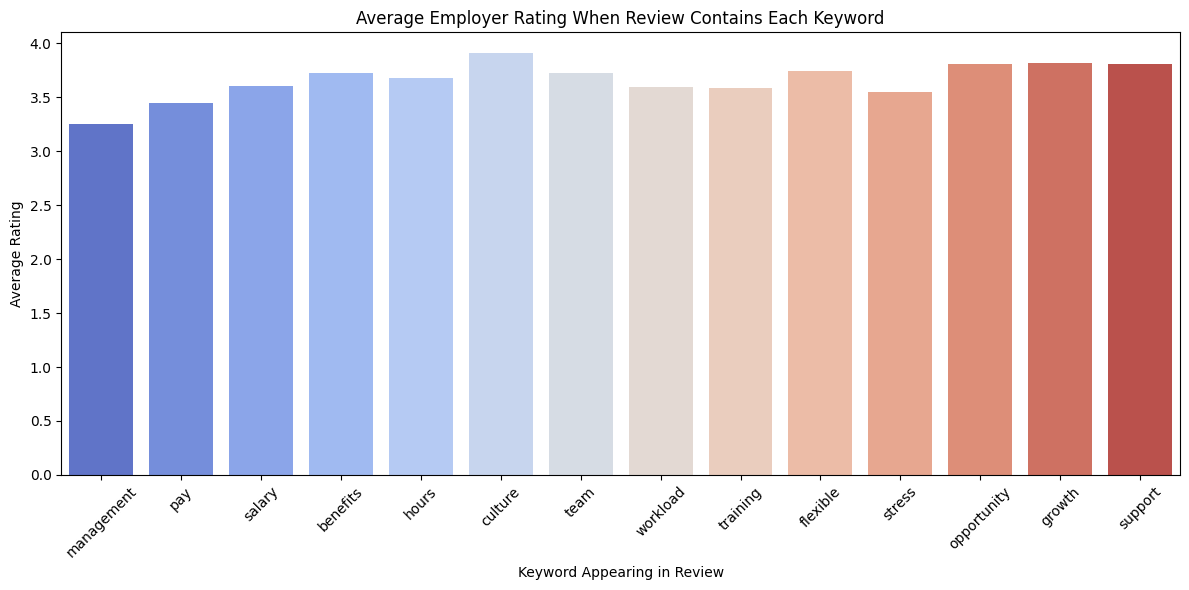

In [30]:
# Average rating by presence of common words
from sklearn.feature_extraction.text import CountVectorizer

# Use a small vocabulary of common managerial keywords
keywords = [
    "management", "pay", "salary", "benefits", "hours",
    "culture", "team", "workload", "training", "flexible",
    "stress", "opportunity", "growth", "support"
]

cv = CountVectorizer(vocabulary=keywords, binary=True)
X_keywords = cv.fit_transform(ds["full_text"])

keyword_df = pd.DataFrame(X_keywords.toarray(), columns=keywords)
keyword_df["rating"] = ds["rating"]

avg_rating = keyword_df.groupby(lambda x: x)[keywords].mean()
avg_rating = keyword_df.groupby("rating").mean()

plt.figure(figsize=(12,6))
sns.barplot(
    x=keywords,
    y=[ds[ds["full_text"].str.contains(w, case=False)].rating.mean() for w in keywords],
    palette="coolwarm"
)
plt.xticks(rotation=45)
plt.title("Average Employer Rating When Review Contains Each Keyword")
plt.ylabel("Average Rating")
plt.xlabel("Keyword Appearing in Review")
plt.tight_layout()
plt.show()

# Q2.

Consider now the data set ”FINAL PC WAGE SIMULATION DATA.csv” which have data on four variables from a simulated economy: wage, text on hiring decision discussion,text on chatbot summary, chatbot interview.

Is there discrimination in this economy? If there is, discuss what type of discrimination, and what type of evidence there is for it. If there is no discrimination, discuss what evidence there supports that view.

Present your argument in 2-6 figures, 0-2 tables, and 100-500 words of text (these are all strict limits).

# Q3.

Consider now the data set ”FINAL PC STOCK SIMULATION DATA.csv” which have data on two variables from a simulated economy: stock market price and company’s annual report.

What happens in this economy during the period covered by the data?

Present your answer in 1-2 figures, 0-1 tables, and 200-1000 words of text (these are all strict limits).